In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

import pickle

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("Mall_Customers.csv")

In [11]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [13]:
df.shape

(200, 5)

In [14]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [15]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [16]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

In [17]:
X = df[features]

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [36]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

In [37]:
clusters = dbscan.fit_predict(X_scaled)

df["Cluster"] = clusters

df["Cluster"].value_counts()

Cluster
-1    60
 2    51
 4    32
 3    28
 0    17
 5     7
 1     5
Name: count, dtype: int64

In [38]:
noise_count = (
    df["Cluster"] == -1
).sum()

print(
    "Noise Customers:",
    noise_count
)

Noise Customers: 60


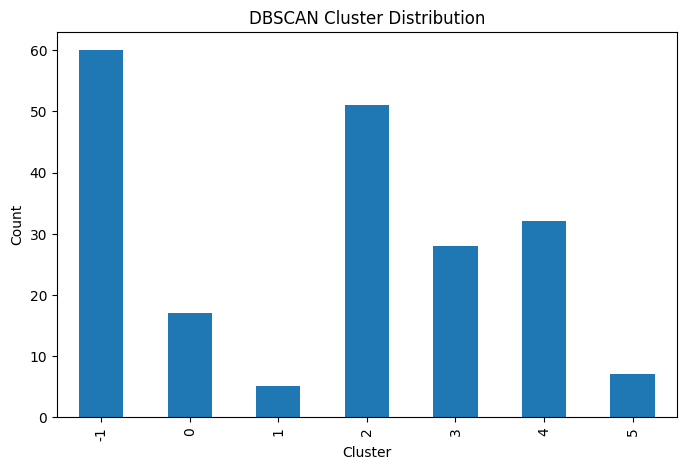

In [39]:
plt.figure(figsize=(8,5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("DBSCAN Cluster Distribution")

plt.show()

In [40]:
cluster_summary = (
    df.groupby("Cluster")[
        features
    ]
    .mean()
)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
-1,40.133333,68.533333,31.533333
0,23.764706,25.823529,78.176471
1,38.200000,27.800000,31.800000
2,53.666667,54.156863,48.411765
3,24.107143,54.321429,50.464286
4,32.750000,80.875000,83.625000
5,43.857143,78.714286,14.571429


In [41]:
pca = PCA(
    n_components=2
)

pca_features = pca.fit_transform(
    X_scaled
)

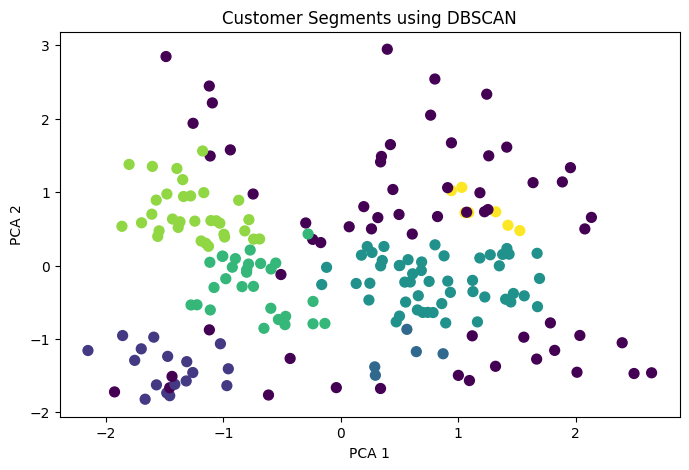

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df["Cluster"],
    s=50
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(
    "Customer Segments using DBSCAN"
)

plt.show()

In [44]:
cluster_names = {
    -1: "Outlier Customers",
    0: "Young High Spenders",
    1: "Low Income Customers",
    2: "Senior Regular Customers",
    3: "Young Regular Customers",
    4: "Premium Customers",
    5: "High Income Low Spenders"
}

In [45]:
df["Cluster_Name"] = (
    df["Cluster"]
    .map(cluster_names)
)

In [46]:
df.to_csv(
    "clustered_customers.csv",
    index=False
)

In [47]:
pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

In [48]:
n_clusters = len(
    set(clusters)
)

print(
    "Total Clusters:",
    n_clusters
)

Total Clusters: 7


In [51]:
for cluster in sorted(
    df["Cluster"].unique()
):
    
    print(
        f"\nCluster {cluster}"
    )
    
    display(
        df[df["Cluster"] == cluster][
            [
                "CustomerID",
                "Genre",
                "Age",
                "Annual Income (k$)",
                "Spending Score (1-100)"
            ]
        ].head()
    )


Cluster -1


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
2,3,Female,20,16,6
4,5,Female,31,17,40
6,7,Female,35,18,6
7,8,Female,23,18,94



Cluster 0


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
1,2,Male,21,15,81
3,4,Female,23,16,77
5,6,Female,22,17,76
9,10,Female,30,19,72
13,14,Female,24,20,77



Cluster 1


...

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
43,44,Female,31,39,61
47,48,Female,27,40,47
48,49,Female,29,40,42
49,50,Female,31,40,42
51,52,Male,33,42,60



Cluster 4


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
123,124,Male,39,69,91
125,126,Female,31,70,77
127,128,Male,40,71,95
129,130,Male,38,71,75
131,132,Male,39,71,75



Cluster 5


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
130,131,Male,47,71,9
136,137,Female,44,73,7
150,151,Male,43,78,17
152,153,Female,44,78,20
154,155,Female,47,78,16
